# Notebook 2: Integrar outputs de pySCENIC con el análisis de Seurat

Este notebook integra los outputs basados en regulones generados en la Notebook 1 con los metadatos y el UMAP exportados de Seurat.

Objetivos principales:
- leer los outputs de SCENIC agrupados en el AnnData generado en la Notebook 1
- leer las anotaciones y metadatos de Seurat a través del objeto ann.loom
- alinear por `CellID`
- construir una tabla maestra integrada a nivel celular
- guardar un objeto integrado en formato `h5ad` para las siguientes notebooks

Adaptado de:
- `SCENICprotocol` del laboratorio de Aerts
- `PBMC10k_downstream-analysis.ipynb`
- flujo general del protocolo SCENIC / pySCENIC

Esta libreta está adaptada a un dataset de HA15 vs Control en un modelo de latencia del VIH-1 con células CD4+ humanas (GSE210824).

In [18]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import loompy as lp

from pathlib import Path


## 1. Definir rutas y datos

En esta libreta se construirá un objeto `AnnData` integrado, guardado en formato `.h5ad`, que conservará la matriz continua de actividad regulónica AUCell como matriz principal y la matriz binaria de regulones como `layer` adicional.

Entrada de pySCENIC procedente de la Notebook 1 (`proc_data/`)

- `01_SCENIC_auc_adata.h5ad`: objeto `AnnData` principal de pySCENIC. Contiene:
  - matriz AUC continua de regulones en `.X`;
  - matriz binaria regulón ON/OFF en `.layers["binary"]`;
  - metadatos celulares de pySCENIC en `.obs`;
  - metadatos de regulones, incluidos los umbrales de binarización, en `.var`;
  - embeddings regulónicos en `.obsm`;
  - clusters regulónicos en `.obs`.

Entrada de Seurat anotado final

- `ann.loom`: objeto exportado desde el Seurat final anotado. Se utilizará como contenedor de:
  - identificadores celulares (`CellID`);
  - metadatos finales de Seurat;
  - anotaciones funcionales;
  - clusters transcriptómicos;
  - estado viral;
  - tratamiento, réplica y muestra;
  - UMAP transcriptómico de Seurat.

Ambos objetos se alinearán por `CellID`, restringiendo el análisis a las células comunes y verificando que el orden celular coincida exactamente. El objeto integrado final mantendrá como núcleo la actividad regulónica de pySCENIC e incorporará los metadatos y embeddings de Seurat para los análisis posteriores.

In [2]:
BASE = Path("/root/TFM/HA15_GSE210824")
RAW = BASE / "raw_data"
PROC = BASE / "proc_data"
RESULTS = BASE / "results"
FIGURES = RESULTS / "figures"
TABLES = RESULTS / "tables"

scenic_h5ad_path = PROC / "01_SCENIC_auc_adata.h5ad"
seurat_loom_path = PROC / "ann.loom"

## 2. Leer outputs de la Notebook 1 y de Seurat

Aquí se usa:
- el `h5ad` generado en la Notebook 1 como contenedor principal de SCENIC
- el loom con las anotaciones de Seurat


A continuación:
- Conectamos ann.loom e inspeccionamos su estructura 

In [3]:
with lp.connect(str(seurat_loom_path), mode="r", validate=False) as lf:
    print("Matrix shape:", lf.shape)
    print("Global attrs:", list(lf.attrs.keys()))
    print("Row attrs:", list(lf.ra.keys()))
    print("Column attrs:", list(lf.ca.keys()))
    print("Layers:", list(lf.layers.keys()))

Matrix shape: (20441, 5312)
Global attrs: ['CreationDate', 'Genome', 'LOOM_SPEC_VERSION', 'MetaData', 'RVersion', 'title']
Row attrs: ['Gene']
Column attrs: ['CellID', 'Embedding', 'Embeddings_X', 'Embeddings_Y', 'HTO_classification', 'HTO_classification.global', 'HTO_margin', 'HTO_maxID', 'HTO_secondID', 'Replicate', 'SCT_snn_res.1', 'SR10_bp', 'SR10_bp_main', 'SR10_dice', 'SR10_dice_clust', 'SR10_dice_main', 'SR10_dice_main_clust', 'SR10_mi', 'SR10_mi_main', 'SR10_nhd', 'SR10_nhd_main', 'SR10_tcells', 'SR10_tcells_clust', 'SR50_bp', 'SR50_bp_main', 'SR50_dice', 'SR50_dice_clust', 'SR50_dice_main', 'SR50_dice_main_clust', 'SR50_mi', 'SR50_mi_main', 'SR50_nhd', 'SR50_nhd_main', 'SR50_tcells', 'SR50_tcells_clust', 'SR_bp', 'SR_bp_main', 'SR_dice', 'SR_dice_clust', 'SR_dice_log', 'SR_dice_main', 'SR_dice_main_clust', 'SR_mi', 'SR_mi_main', 'SR_nhd', 'SR_nhd_main', 'SR_tcells', 'Sample', 'Treatment', 'cd4_L1', 'cd4_L1_prob', 'cd4_L2', 'cd4_L2_prob', 'celltypist_confscore', 'celltypist_maj

In [4]:
# extraer metadatos de Seurat desde el loom

with lp.connect(str(seurat_loom_path), mode="r", validate=False) as lf:
    cell_ids = lf.ca["CellID"].astype(str)

    seurat_meta = pd.DataFrame(
        {
            key: lf.ca[key]
            for key in lf.ca.keys()
            if key not in ["CellID", "Embedding", "Embeddings_X", "Embeddings_Y"]
        },
        index=cell_ids
    )

seurat_meta.index.name = "CellID"

print("seurat_meta:", seurat_meta.shape)
print(seurat_meta.columns.tolist())

seurat_meta: (5312, 92)
['HTO_classification', 'HTO_classification.global', 'HTO_margin', 'HTO_maxID', 'HTO_secondID', 'Replicate', 'SCT_snn_res.1', 'SR10_bp', 'SR10_bp_main', 'SR10_dice', 'SR10_dice_clust', 'SR10_dice_main', 'SR10_dice_main_clust', 'SR10_mi', 'SR10_mi_main', 'SR10_nhd', 'SR10_nhd_main', 'SR10_tcells', 'SR10_tcells_clust', 'SR50_bp', 'SR50_bp_main', 'SR50_dice', 'SR50_dice_clust', 'SR50_dice_main', 'SR50_dice_main_clust', 'SR50_mi', 'SR50_mi_main', 'SR50_nhd', 'SR50_nhd_main', 'SR50_tcells', 'SR50_tcells_clust', 'SR_bp', 'SR_bp_main', 'SR_dice', 'SR_dice_clust', 'SR_dice_log', 'SR_dice_main', 'SR_dice_main_clust', 'SR_mi', 'SR_mi_main', 'SR_nhd', 'SR_nhd_main', 'SR_tcells', 'Sample', 'Treatment', 'cd4_L1', 'cd4_L1_prob', 'cd4_L2', 'cd4_L2_prob', 'celltypist_confscore', 'celltypist_majority', 'celltypist_predicted', 'functional_ann', 'functional_ann2', 'hash.ID', 'miQC.keep', 'miQC.probability', 'nCount_HTO', 'nCount_RNA', 'nCount_SCT', 'nFeature_HTO', 'nFeature_RNA', '

In [5]:
#extraer UMAP de Seurat desde el loom

with lp.connect(str(seurat_loom_path), mode="r", validate=False) as lf:
    seurat_umap = pd.DataFrame(
        {
            "Seurat_UMAP_1": lf.ca["Embedding"]["_X"],
            "Seurat_UMAP_2": lf.ca["Embedding"]["_Y"],
        },
        index=lf.ca["CellID"].astype(str)
    )

seurat_umap.index.name = "CellID"

print("seurat_umap:", seurat_umap.shape)
seurat_umap.head()

seurat_umap: (5312, 2)


,Seurat_UMAP_1,Seurat_UMAP_2
CellID,,
CACCAAAAGCCGATCT,-7.560176,-4.140408
CTAGACAAGCTACCGT,-7.448501,-3.746405
GTAATCGAGCGATTAG,-7.590543,-4.512128
ATAGACCCACCAGCCA,-7.364254,-3.838973
ATCGTCCTCATTGACA,-7.416118,-3.869999


- Cargamos AnnData de la libreta 1

In [6]:
adata_scenic = sc.read_h5ad(scenic_h5ad_path)

print(adata_scenic)
print("obs:", list(adata_scenic.obs.columns))
print("var:", list(adata_scenic.var.columns))
print("layers:", list(adata_scenic.layers.keys()))
print("obsm:", list(adata_scenic.obsm.keys()))

AnnData object with n_obs × n_vars = 5312 × 276
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'Sample', 'Treatment', 'Replicate', 'percent.mt', 'percent.ribo', 'miQC.probability', 'miQC.keep', 'SCENIC_cluster_L1', 'SCENIC_cluster_L2'
    var: 'threshold'
    uns: 'Replicate_colors', 'SCENIC_cluster_L1', 'SCENIC_cluster_L1_colors', 'SCENIC_cluster_L2', 'SCENIC_cluster_L2_colors', 'Treatment_colors', 'neighbors', 'tsne', 'umap'
    obsm: 'X_tsne', 'X_umap'
    layers: 'binary'
    obsp: 'connectivities', 'distances'
obs: ['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'Sample', 'Treatment', 'Replicate', 'percent.mt', 'percent.ribo', 'miQC.probability', 'miQC.keep', 'SCENIC_cluster_L1', 'SCENIC_cluster_L2']
var: ['thres

- Antes de realizar la integración, se restringe el análisis a las células compartidas entre todas las fuentes de datos.

La integración se basa en la intersección exacta por `CellID`, y todos los objetos se reordenan con ese criterio para garantizar un alineamiento consistente y reproducible.


In [7]:
adata_scenic.obs_names = adata_scenic.obs_names.astype(str)

n_scenic_before = adata_scenic.n_obs
n_seurat_before = seurat_meta.shape[0]

common_cells = pd.Index(
    adata_scenic.obs_names[adata_scenic.obs_names.isin(seurat_meta.index)],
    name="CellID"
)

adata_scenic = adata_scenic[common_cells, :].copy()
seurat_meta = seurat_meta.loc[common_cells].copy()
seurat_umap = seurat_umap.loc[common_cells].copy()

print("SCENIC cells before:", n_scenic_before)
print("Seurat cells before:", n_seurat_before)
print("Common cells:", len(common_cells))
print("Cells excluded from SCENIC:", n_scenic_before - len(common_cells))
print("Cells excluded from Seurat:", n_seurat_before - len(common_cells))
print("Identical order metadata:", adata_scenic.obs_names.tolist() == seurat_meta.index.tolist())
print("Identical order UMAP:", adata_scenic.obs_names.tolist() == seurat_umap.index.tolist())

SCENIC cells before: 5312
Seurat cells before: 5312
Common cells: 5312
Cells excluded from SCENIC: 0
Cells excluded from Seurat: 0
Identical order metadata: True
Identical order UMAP: True


## 3. Construir el objeto AnnData integrado

Se parte del objeto `adata_scenic` como núcleo del análisis, manteniendo la matriz continua de actividad regulónica AUCell en `.X`, la matriz binaria en `.layers["binary"]`, los umbrales de binarización en `.var` y los embeddings regulónicos en `.obsm`.

A continuación, se incorporan los metadatos del Seurat final anotado y el UMAP transcriptómico de Seurat. Cuando una columna ya existe tanto en `adata_scenic.obs` como en los metadatos de Seurat, se prioriza la versión procedente de Seurat para mantener la coherencia con el análisis transcriptómico final.


In [8]:
adata_int = adata_scenic.copy()

shared_cols = adata_int.obs.columns.intersection(seurat_meta.columns)

print("Columnas compartidas que se reemplazan por versión Seurat:")
print(shared_cols.tolist())

adata_int.obs = adata_int.obs.drop(columns=shared_cols)
adata_int.obs = pd.concat([adata_int.obs, seurat_meta], axis=1)

adata_int.obsm["X_umap_seurat"] = seurat_umap[["Seurat_UMAP_1", "Seurat_UMAP_2"]].to_numpy()

print(adata_int)
print("obs:", adata_int.obs.shape)
print("var:", adata_int.var.shape)
print("layers:", list(adata_int.layers.keys()))
print("obsm:", list(adata_int.obsm.keys()))

Columnas compartidas que se reemplazan por versión Seurat:
['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'Sample', 'Treatment', 'Replicate', 'percent.mt', 'percent.ribo', 'miQC.probability', 'miQC.keep']
AnnData object with n_obs × n_vars = 5312 × 276
    obs: 'SCENIC_cluster_L1', 'SCENIC_cluster_L2', 'HTO_classification', 'HTO_classification.global', 'HTO_margin', 'HTO_maxID', 'HTO_secondID', 'Replicate', 'SCT_snn_res.1', 'SR10_bp', 'SR10_bp_main', 'SR10_dice', 'SR10_dice_clust', 'SR10_dice_main', 'SR10_dice_main_clust', 'SR10_mi', 'SR10_mi_main', 'SR10_nhd', 'SR10_nhd_main', 'SR10_tcells', 'SR10_tcells_clust', 'SR50_bp', 'SR50_bp_main', 'SR50_dice', 'SR50_dice_clust', 'SR50_dice_main', 'SR50_dice_main_clust', 'SR50_mi', 'SR50_mi_main', 'SR50_nhd', 'SR50_nhd_main', 'SR50_tcells', 'SR50_tcells_clust', 'SR_bp', 'SR_bp_main', 'SR_dice', 'SR_dice_clust', 'S

## 4. Comprobaciones finales y guardado del objeto integrado

Se comprueba que el objeto integrado conserva la estructura esperada: matriz AUC continua como matriz principal, matriz binaria como `layer`, umbrales de binarización en `.var`, metadatos celulares finales en `.obs` y embeddings regulónicos y transcriptómicos en `.obsm`.

El objeto se guarda en formato `.h5ad` para utilizarlo como entrada en la siguiente libreta de análisis de regulones.

In [9]:
print("Shape:", adata_int.shape)

print("Layer binary present:", "binary" in adata_int.layers)
if "binary" in adata_int.layers:
    print("Binary shape:", adata_int.layers["binary"].shape)

print("Thresholds in var:", "threshold" in adata_int.var.columns)
if "threshold" in adata_int.var.columns:
    print("Number of thresholds:", adata_int.var["threshold"].notna().sum())

print("Embeddings present:", list(adata_int.obsm.keys()))

required_obsm = ["X_umap", "X_tsne", "X_umap_seurat"]
missing_obsm = [key for key in required_obsm if key not in adata_int.obsm]
print("Missing required obsm:", missing_obsm)

required_obs = ["SCENIC_cluster_L1", "SCENIC_cluster_L2", "seurat_clusters", "functional_ann",
    "functional_ann2", "Treatment", "Replicate", "Sample"]

missing_obs = [col for col in required_obs if col not in adata_int.obs.columns]
print("Missing required obs columns:", missing_obs)

seurat_only_cols = [col for col in seurat_meta.columns if col in adata_int.obs.columns]
print("Seurat metadata columns integrated:", len(seurat_only_cols))
print(seurat_only_cols)

print("NA counts in required obs columns:")
print(adata_int.obs[required_obs].isna().sum())

print("Categories / unique values in key columns:")
for col in required_obs:
    print(col, adata_int.obs[col].nunique(), adata_int.obs[col].unique().tolist()[:20])

adata_int.write(PROC / "02_SCENIC_Seurat_integrated_adata.h5ad")

Shape: (5312, 276)
Layer binary present: True
Binary shape: (5312, 276)
Thresholds in var: True
Number of thresholds: 276
Embeddings present: ['X_tsne', 'X_umap', 'X_umap_seurat']
Missing required obsm: []
Missing required obs columns: []
Seurat metadata columns integrated: 92
['HTO_classification', 'HTO_classification.global', 'HTO_margin', 'HTO_maxID', 'HTO_secondID', 'Replicate', 'SCT_snn_res.1', 'SR10_bp', 'SR10_bp_main', 'SR10_dice', 'SR10_dice_clust', 'SR10_dice_main', 'SR10_dice_main_clust', 'SR10_mi', 'SR10_mi_main', 'SR10_nhd', 'SR10_nhd_main', 'SR10_tcells', 'SR10_tcells_clust', 'SR50_bp', 'SR50_bp_main', 'SR50_dice', 'SR50_dice_clust', 'SR50_dice_main', 'SR50_dice_main_clust', 'SR50_mi', 'SR50_mi_main', 'SR50_nhd', 'SR50_nhd_main', 'SR50_tcells', 'SR50_tcells_clust', 'SR_bp', 'SR_bp_main', 'SR_dice', 'SR_dice_clust', 'SR_dice_log', 'SR_dice_main', 'SR_dice_main_clust', 'SR_mi', 'SR_mi_main', 'SR_nhd', 'SR_nhd_main', 'SR_tcells', 'Sample', 'Treatment', 'cd4_L1', 'cd4_L1_prob'

In [10]:
adata_int.obs.head()

,SCENIC_cluster_L1,SCENIC_cluster_L2,HTO_classification,HTO_classification.global,HTO_margin,HTO_maxID,HTO_secondID,Replicate,SCT_snn_res.1,SR10_bp,...,scType2_panglao_t,scType3,scType3_cd4,scType3_cm_hu,scType3_cm_sc,scType3_panglao,scType3_panglao_t,scType_conf,scType_conf_cd4,seurat_clusters
CellID,,,,,,,,,,,,,,,,,,,,,
CACCAAAAGCCGATCT,3,6,Hashtag-1,Singlet,5.048565,Hashtag-1,Hashtag-9,Rep1,8,DC,...,Erythroblasts,Platelets,Effector CD4+ T cells,Proliferative cell,Proliferative cell,Erythroid-like and erythroid precursor cells,Erythroid-like and erythroid precursor cells,36.0,100.0,8
CTAGACAAGCTACCGT,3,6,Hashtag-1,Singlet,5.466845,Hashtag-1,Hashtag-4,Rep1,8,Melanocytes,...,Erythroblasts,Platelets,Effector CD4+ T cells,Proliferative cell,Proliferative cell,Erythroid-like and erythroid precursor cells,Erythroid-like and erythroid precursor cells,36.0,100.0,8
GTAATCGAGCGATTAG,3,6,Hashtag-1,Singlet,5.640338,Hashtag-1,Hashtag-4,Rep1,8,Erythrocytes,...,Erythroblasts,Platelets,Effector CD4+ T cells,Proliferative cell,Proliferative cell,Erythroid-like and erythroid precursor cells,Erythroid-like and erythroid precursor cells,36.0,100.0,8
ATAGACCCACCAGCCA,3,6,Hashtag-3,Singlet,5.744484,Hashtag-3,Hashtag-9,Rep3,8,DC,...,Erythroblasts,Platelets,Effector CD4+ T cells,Proliferative cell,Proliferative cell,Erythroid-like and erythroid precursor cells,Erythroid-like and erythroid precursor cells,36.0,100.0,8
ATCGTCCTCATTGACA,3,6,Hashtag-4,Singlet,4.651927,Hashtag-4,Hashtag-5,Rep1,8,GMP,...,Erythroblasts,Platelets,Effector CD4+ T cells,Proliferative cell,Proliferative cell,Erythroid-like and erythroid precursor cells,Erythroid-like and erythroid precursor cells,36.0,100.0,8


Guardado de tablas de control para inspeccionar la integración.


## 5. QC visual de la integración

Se visualizan:

- el UMAP basado en regulones de SCENIC, almacenado en `.obsm["X_umap"]`;
- el UMAP transcriptómico de Seurat, almacenado en `.obsm["X_umap_seurat"]`.

Esto permite comprobar que los metadatos y anotaciones finales de Seurat se proyectan correctamente tanto sobre el espacio regulónico como sobre el embedding transcriptómico original.

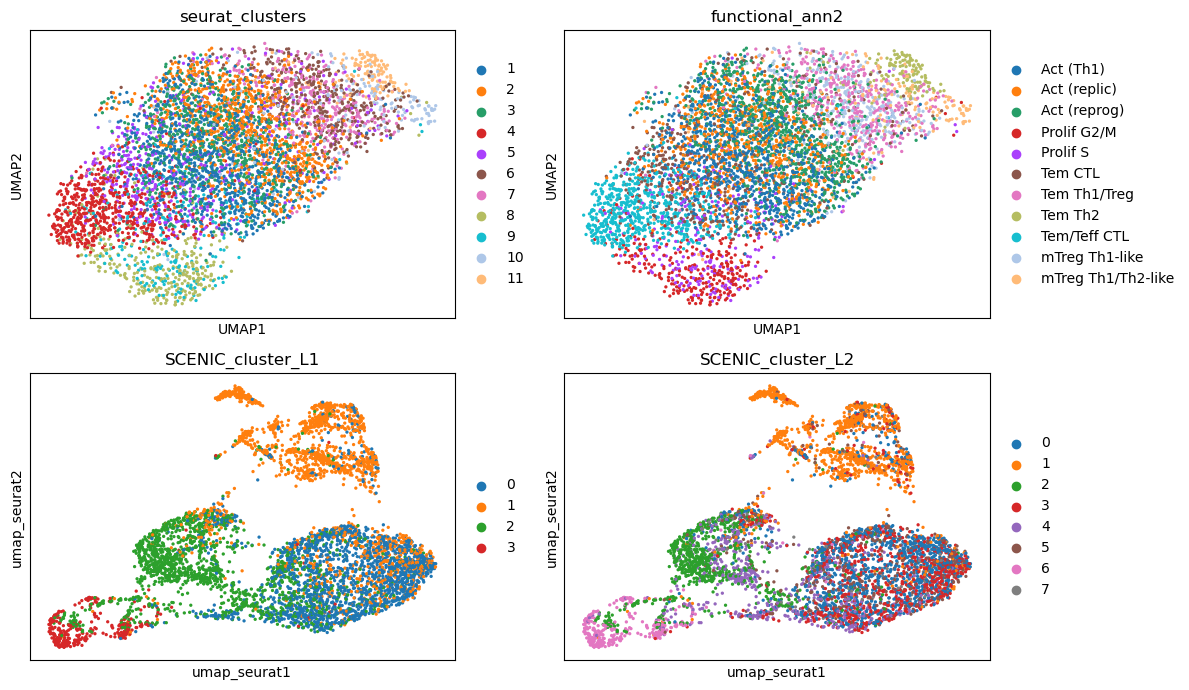

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

plots = [
    ("umap", "seurat_clusters", axes[0, 0]),
    ("umap", "functional_ann2", axes[0, 1]),
    ("umap_seurat", "SCENIC_cluster_L1", axes[1, 0]),
    ("umap_seurat", "SCENIC_cluster_L2", axes[1, 1]),
]

for basis, color, ax in plots:
    sc.pl.embedding(
        adata_int,
        basis=basis,
        color=color,
        ax=ax,
        show=False,
    )

plt.tight_layout()
plt.savefig(FIGURES / "02_integration_scenic_seurat_cross_umaps.png", dpi=300, bbox_inches="tight")
plt.show()


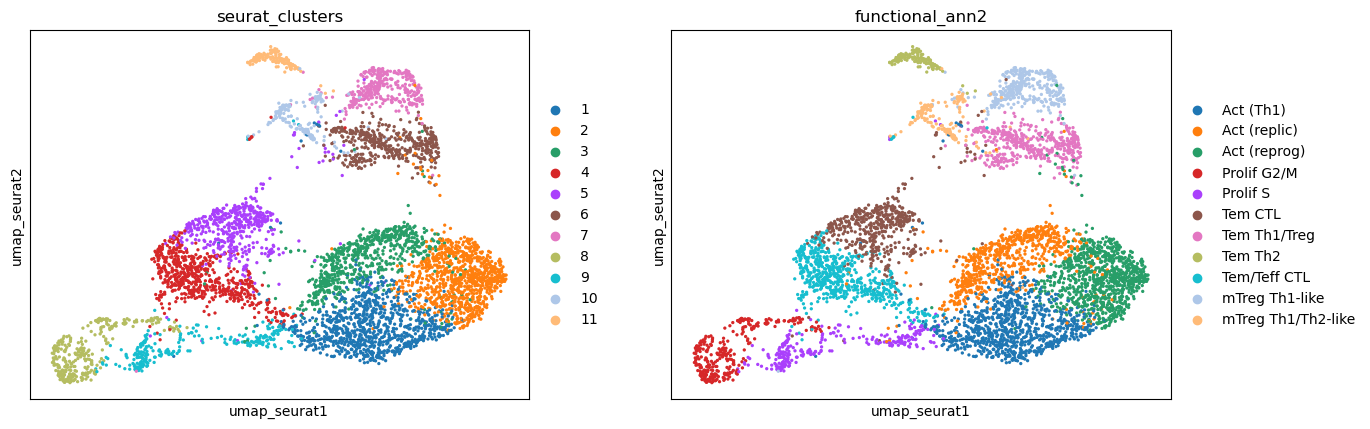

In [12]:
sc.pl.embedding(
    adata_int,
    basis="umap_seurat",
    color=["seurat_clusters", "functional_ann2"],
    ncols=2,
    wspace=0.17,
    show=False,
)

plt.savefig(FIGURES / "02_integration_seurat_umap_seurat_annotations.png", dpi=300, bbox_inches="tight")
plt.show()

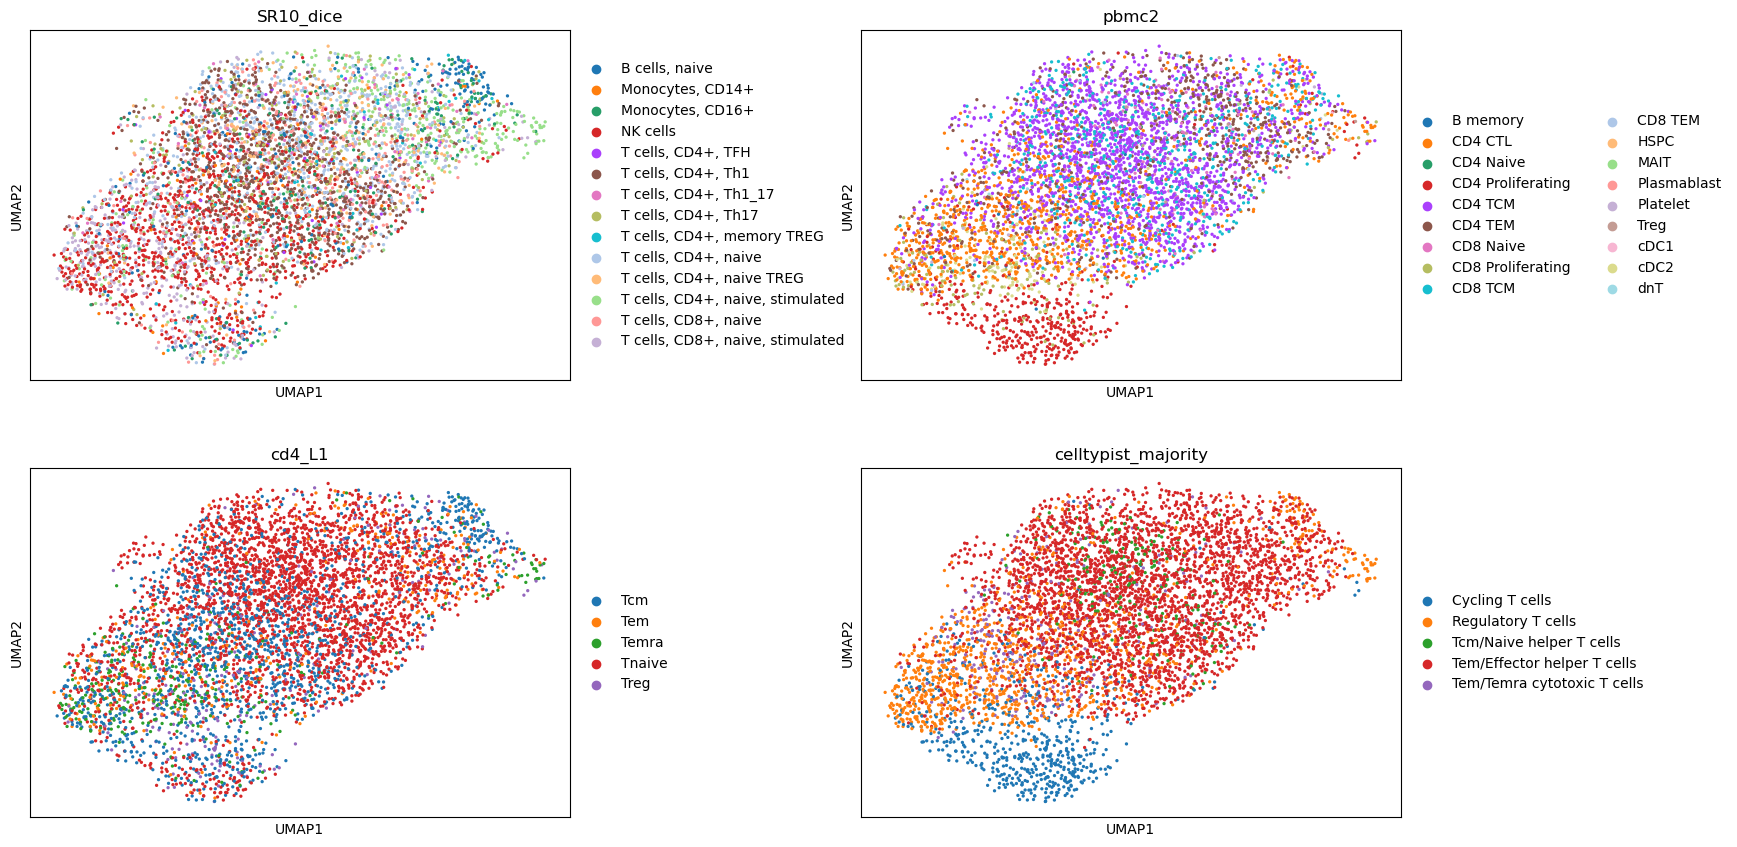

In [13]:
auto_ann_vars = [
    "SR10_dice",
    "pbmc2",
    "cd4_L1",
    "celltypist_majority",
]

auto_ann_vars = [c for c in auto_ann_vars if c in adata_int.obs.columns]

sc.pl.umap(
    adata_int,
    color=auto_ann_vars,
    ncols=2,
    wspace=0.4,
    show=False,
)

plt.savefig(FIGURES / "02_integration_scenic_umap_auto_annotations.png", dpi=300, bbox_inches="tight")
plt.show()

- se añaden los counts de VIH+

In [14]:
with lp.connect(str(seurat_loom_path), mode="r", validate=False) as lf:
    genes = pd.Index(lf.ra["Gene"].astype(str))
    cell_ids = pd.Index(lf.ca["CellID"].astype(str), name="CellID")

    tat_rows = np.where(genes == "Tat")[0]
    rev_rows = np.where(genes == "Rev")[0]

    print("Tat rows:", tat_rows)
    print("Rev rows:", rev_rows)

    tat_counts = lf[tat_rows, :].sum(axis=0)
    rev_counts = lf[rev_rows, :].sum(axis=0)

hiv_status = pd.Series(
    np.where((tat_counts > 0) | (rev_counts > 0), "HIV+", "HIV-"),
    index=cell_ids,
    name="HIV_status"
)

adata_int.obs["HIV_status"] = hiv_status.loc[adata_int.obs_names].values

print(adata_int.obs["HIV_status"].value_counts())

Tat rows: [17750]
Rev rows: [15077]
HIV_status
HIV-    4284
HIV+    1028
Name: count, dtype: int64


<Axes: title={'center': 'HIV_status'}, xlabel='UMAP1', ylabel='UMAP2'>

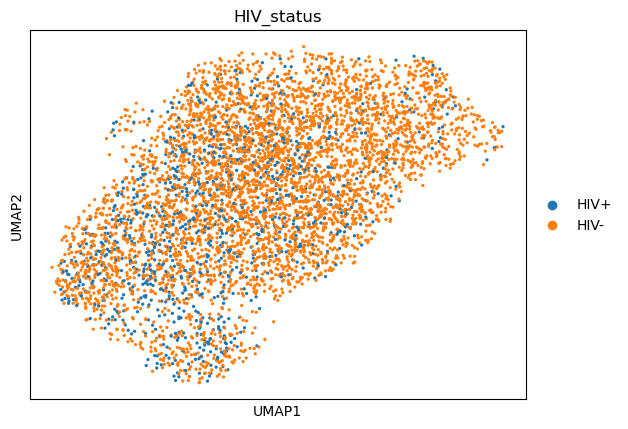

In [15]:
sc.pl.umap(
    adata_int,
    color="HIV_status",
    wspace=0.17,
    show=False,
)

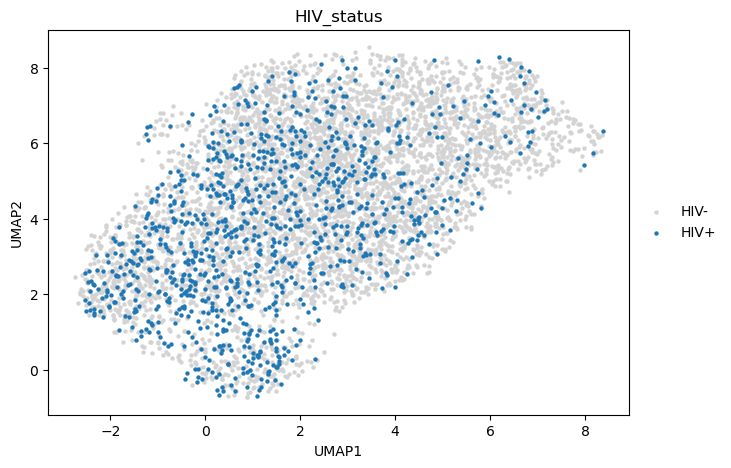

In [16]:
umap = adata_int.obsm["X_umap"]
hiv = adata_int.obs["HIV_status"].astype(str)

mask_neg = hiv == "HIV-"
mask_pos = hiv == "HIV+"

fig, ax = plt.subplots(figsize=(7.5, 5))

ax.scatter(
    umap[mask_neg, 0],
    umap[mask_neg, 1],
    s=10,
    c="lightgray",
    linewidths=0,
    label="HIV-",
)

ax.scatter(
    umap[mask_pos, 0],
    umap[mask_pos, 1],
    s=10,
    c="#1f77b4",
    linewidths=0,
    label="HIV+",
)

ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("HIV_status")
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1, 0.5))

plt.savefig(FIGURES / "02_scenic_umap_HIV_status_overlay.png", dpi=300, bbox_inches="tight")
plt.show()

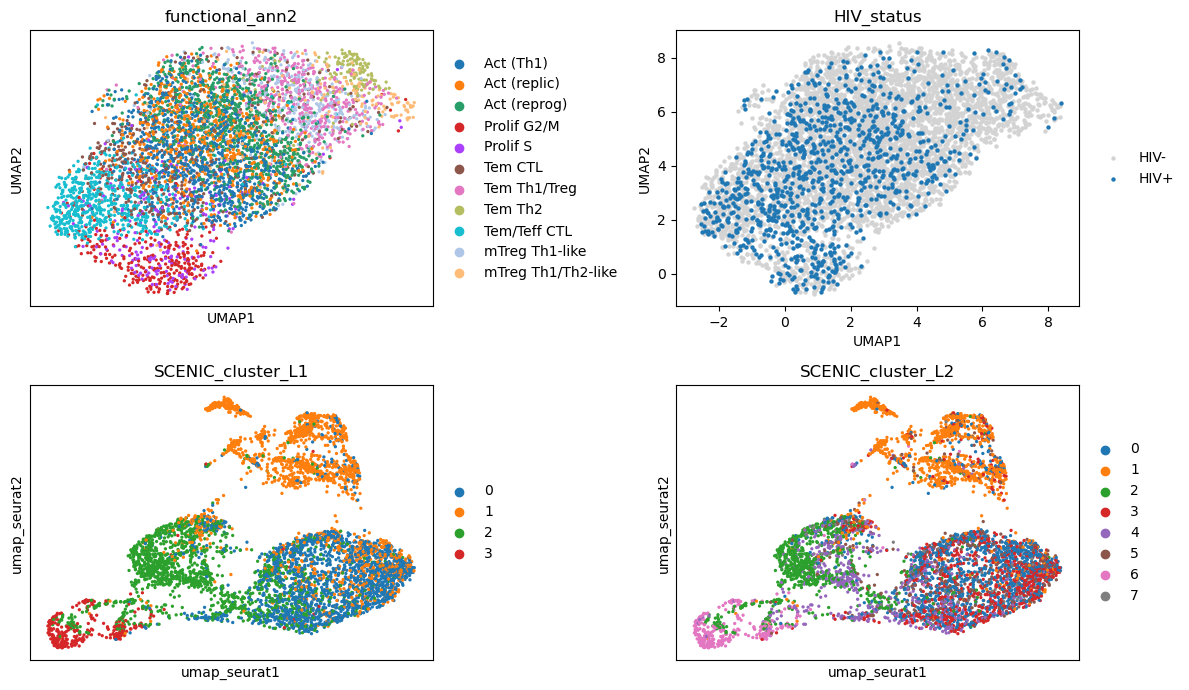

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

# Panel 1: functional_ann2 sobre UMAP regulónico
sc.pl.embedding(
    adata_int,
    basis="umap",
    color="functional_ann2",
    ax=axes[0, 0],
    show=False,
)

# Panel 2: HIV_status sobre UMAP regulónico, HIV+ encima
umap = adata_int.obsm["X_umap"]
hiv = adata_int.obs["HIV_status"].astype(str)

mask_neg = hiv == "HIV-"
mask_pos = hiv == "HIV+"

axes[0, 1].scatter(
    umap[mask_neg, 0],
    umap[mask_neg, 1],
    s=10,
    c="lightgray",
    linewidths=0,
    label="HIV-",
)

axes[0, 1].scatter(
    umap[mask_pos, 0],
    umap[mask_pos, 1],
    s=10,
    c="#1f77b4",
    linewidths=0,
    label="HIV+",
)

axes[0, 1].set_xlabel("UMAP1")
axes[0, 1].set_ylabel("UMAP2")
axes[0, 1].set_title("HIV_status")
axes[0, 1].legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))

# Paneles 3-4: clusters SCENIC sobre UMAP Seurat
sc.pl.embedding(
    adata_int,
    basis="umap_seurat",
    color="SCENIC_cluster_L1",
    ax=axes[1, 0],
    show=False,
)

sc.pl.embedding(
    adata_int,
    basis="umap_seurat",
    color="SCENIC_cluster_L2",
    ax=axes[1, 1],
    show=False,
)

plt.tight_layout()
plt.savefig(FIGURES / "02_integration_scenic_seurat_cross_umaps2.png", dpi=300, bbox_inches="tight")
plt.show()